# Deepverse vs DeepMIMO: 종합 비교 분석

이 노트북은 두 무선 채널 데이터셋인 **Deepverse (DT31)** 와 **DeepMIMO (O2_dyn_3p5)** 의 주요 특성을 비교 분석합니다.

## 분석 목차
1. 데이터셋 기본 정보 비교
2. 데이터 로딩 및 구조 분석
3. 채널 특성 비교 (경로 손실, 다중경로, 각도)
4. **Scene 간 Interval Time 분석**
5. 시계열 특성 비교
6. 센서 모달리티 비교
7. 종합 요약 및 시각화

In [1]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# 경로 설정
DEEPVERSE_ROOT = '/mnt/ssd_7t_2/Deepverse'
DEEPMIMO_ROOT  = '/mnt/ssd_7t_2/DeepMIMO'
DV_SCENARIO    = os.path.join(DEEPVERSE_ROOT, 'scenarios', 'DT31')
DM_SCENARIO    = os.path.join(DEEPMIMO_ROOT, 'O2_dyn_3p5')

print('=== 경로 확인 ===')
print(f'Deepverse 시나리오 경로 존재: {os.path.exists(DV_SCENARIO)}')
print(f'DeepMIMO  시나리오 경로 존재: {os.path.exists(DM_SCENARIO)}')

# 한글 폰트 설정 (없으면 영어로 출력)
try:
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 6)

=== 경로 확인 ===
Deepverse 시나리오 경로 존재: True
DeepMIMO  시나리오 경로 존재: True


---
## 1. 데이터셋 기본 정보 비교

In [2]:
# ──────────────────────────────────────────────
# 1-1. 파일 수 / 폴더 수 집계
# ──────────────────────────────────────────────

def count_files(root, ext=None):
    total = 0
    for dirpath, _, files in os.walk(root):
        for f in files:
            if ext is None or f.endswith(ext):
                total += 1
    return total

dv_scenes = sorted([d for d in os.listdir(os.path.join(DV_SCENARIO, 'wireless'))
                    if os.path.isdir(os.path.join(DV_SCENARIO, 'wireless', d))])
dm_scenes = sorted([d for d in os.listdir(DM_SCENARIO)
                    if d.startswith('scene_') and
                       os.path.isdir(os.path.join(DM_SCENARIO, d))],
                   key=lambda x: int(x.split('_')[1]))

dv_img_files  = glob.glob(os.path.join(DV_SCENARIO, 'RGB_images', '**', '*.png'),  recursive=True)
dv_pcd_files  = glob.glob(os.path.join(DV_SCENARIO, 'lidar',      '**', '*.pcd'),  recursive=True)
dv_mat_files  = glob.glob(os.path.join(DV_SCENARIO, 'wireless',   '**', '*.mat'),  recursive=True)
dm_mat_files  = glob.glob(os.path.join(DM_SCENARIO, '**', '*.mat'), recursive=True)

print('=' * 60)
print('         데이터셋 기본 통계 비교')
print('=' * 60)
print(f"{'항목':<28} {'Deepverse (DT31)':>15} {'DeepMIMO (O2_dyn_3p5)':>22}")
print('-' * 67)
rows = [
    ('총 Scene 수',          len(dv_scenes),              len(dm_scenes)),
    ('무선 MAT 파일 수',     len(dv_mat_files),           len(dm_mat_files)),
    ('RGB 이미지 수',        len(dv_img_files),           'N/A'),
    ('LiDAR PCD 파일 수',    len(dv_pcd_files),           'N/A'),
    ('반송파 주파수 (GHz)',   60,                          3.5),
    ('BS 안테나 수',         16,                          'Dataset 내 명시'),
    ('UE 안테나 수',         1,                           1),
    ('시나리오 환경',         'Indoor (실내)',              'Urban Outdoor (실외)'),
    ('데이터 형식',           'Deepverse API / MAT',       'DeepMIMOv3 / MAT'),
    ('시뮬레이터',            'Wireless InSite',           'Wireless InSite'),
]
for name, dv, dm in rows:
    print(f"{name:<28} {str(dv):>15} {str(dm):>22}")
print('=' * 60)

         데이터셋 기본 통계 비교
항목                           Deepverse (DT31)  DeepMIMO (O2_dyn_3p5)
-------------------------------------------------------------------
총 Scene 수                               7012                   1000
무선 MAT 파일 수                            14025                  27000
RGB 이미지 수                               7012                    N/A
LiDAR PCD 파일 수                          7012                    N/A
반송파 주파수 (GHz)                             60                    3.5
BS 안테나 수                                  16           Dataset 내 명시
UE 안테나 수                                   1                      1
시나리오 환경                          Indoor (실내)     Urban Outdoor (실외)
데이터 형식                       Deepverse API / MAT       DeepMIMOv3 / MAT
시뮬레이터                        Wireless InSite        Wireless InSite


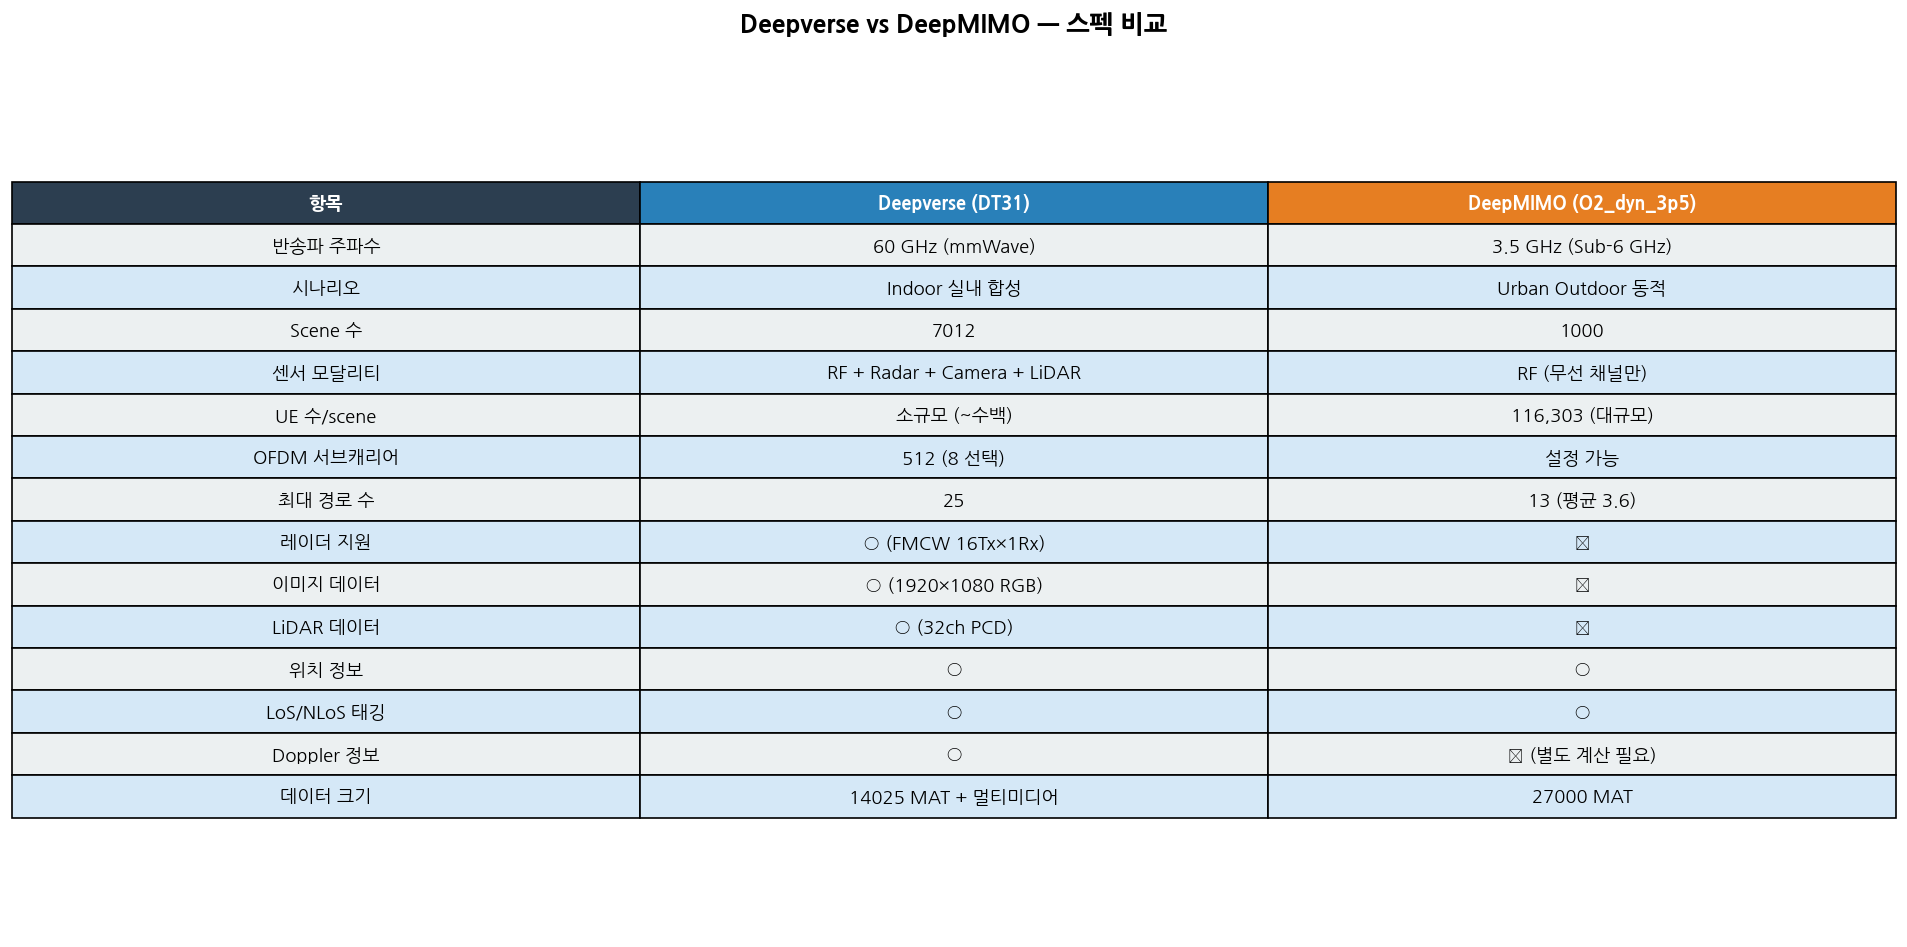

In [3]:
# ──────────────────────────────────────────────
# 1-2. 시각적 스펙 비교표
# ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')

columns = ['항목', 'Deepverse (DT31)', 'DeepMIMO (O2_dyn_3p5)']
table_data = [
    ['반송파 주파수',      '60 GHz (mmWave)',        '3.5 GHz (Sub-6 GHz)'],
    ['시나리오',          'Indoor 실내 합성',        'Urban Outdoor 동적'],
    ['Scene 수',          str(len(dv_scenes)),        str(len(dm_scenes))],
    ['센서 모달리티',      'RF + Radar + Camera + LiDAR', 'RF (무선 채널만)'],
    ['UE 수/scene',       '소규모 (~수백)',           '116,303 (대규모)'],
    ['OFDM 서브캐리어',   '512 (8 선택)',             '설정 가능'],
    ['최대 경로 수',       '25',                      '13 (평균 3.6)'],
    ['레이더 지원',        '○ (FMCW 16Tx×1Rx)',      '✕'],
    ['이미지 데이터',      '○ (1920×1080 RGB)',       '✕'],
    ['LiDAR 데이터',      '○ (32ch PCD)',             '✕'],
    ['위치 정보',          '○',                       '○'],
    ['LoS/NLoS 태깅',     '○',                       '○'],
    ['Doppler 정보',      '○',                       '✕ (별도 계산 필요)'],
    ['데이터 크기',        f'{len(dv_mat_files)} MAT + 멀티미디어', f'{len(dm_mat_files)} MAT'],
]

colors_header = [['#2c3e50','#2980b9','#e67e22']]
colors_body   = []
for i, row in enumerate(table_data):
    base = '#ecf0f1' if i % 2 == 0 else '#d5e8f7'
    colors_body.append([base, base, base])

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    cellColours=colors_body,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)

# 헤더 색상
for col in range(3):
    tbl[(0, col)].set_facecolor(['#2c3e50','#2980b9','#e67e22'][col])
    tbl[(0, col)].set_text_props(color='white', fontweight='bold')

ax.set_title('Deepverse vs DeepMIMO — 스펙 비교', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(DEEPVERSE_ROOT, 'comparison_spec_table.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2. 데이터 로딩 및 구조 분석

In [4]:
# ──────────────────────────────────────────────
# 2-1. Deepverse — 첫 번째 scene 로드
# ──────────────────────────────────────────────

dv_scene_path = os.path.join(DV_SCENARIO, 'wireless', dv_scenes[0])
dv_mat_list   = sorted(glob.glob(os.path.join(dv_scene_path, '*.mat')))

print(f'[Deepverse] 첫 scene: {dv_scenes[0]}')
print(f'  MAT 파일 목록: {[os.path.basename(f) for f in dv_mat_list]}')

dv_sample = None
if dv_mat_list:
    try:
        import deepverse as dv
        print('  Deepverse API 사용 가능')
    except ImportError:
        print('  Deepverse API 없음 → scipy.io.loadmat 사용')

    dv_raw = sio.loadmat(dv_mat_list[0], simplify_cells=True)
    print(f'  MAT 파일 최상위 키: {[k for k in dv_raw.keys() if not k.startswith("_")]}')
    dv_sample = dv_raw
    
    # 주요 키 탐색
    for key in dv_raw:
        if key.startswith('_'): continue
        val = dv_raw[key]
        if isinstance(val, np.ndarray):
            print(f'    {key}: shape={val.shape}, dtype={val.dtype}')
        elif isinstance(val, dict):
            print(f'    {key}: dict with keys={list(val.keys())[:5]}')
        else:
            print(f'    {key}: type={type(val).__name__}, value={str(val)[:80]}')

[Deepverse] 첫 scene: scene_0
  MAT 파일 목록: ['BS1_BS.mat', 'BS1_UE_0-1.mat']
  Deepverse API 사용 가능
  MAT 파일 최상위 키: ['channels', 'rx_locs', 'tx_loc']
    channels: dict with keys=['p']
    rx_locs: shape=(5,), dtype=float32
    tx_loc: shape=(3,), dtype=float32


In [5]:
# ──────────────────────────────────────────────
# 2-2. DeepMIMO — 첫 번째 scene 로드 (CIR + params)
# ──────────────────────────────────────────────

dm_scene0_path = os.path.join(DM_SCENARIO, 'scene_0')
dm_mat_list_s0 = sorted(glob.glob(os.path.join(dm_scene0_path, '*.mat')))

print(f'[DeepMIMO] scene_0 MAT 파일:')
for f in dm_mat_list_s0:
    print(f'  {os.path.basename(f)}')

# params 로드
dm_params_path = os.path.join(dm_scene0_path, 'O2_dyn_3p5.params.mat')
if os.path.exists(dm_params_path):
    dm_params = sio.loadmat(dm_params_path, simplify_cells=True)
    print(f'\n[DeepMIMO params 키]: {[k for k in dm_params.keys() if not k.startswith("_")]}')
    for key, val in dm_params.items():
        if key.startswith('_'): continue
        if isinstance(val, np.ndarray):
            print(f'  {key}: shape={val.shape}, dtype={val.dtype}')
        else:
            print(f'  {key}: {str(val)[:120]}')

# CIR 로드
dm_cir_path = os.path.join(dm_scene0_path, 'O2_dyn_3p5.1.CIR.mat')
if os.path.exists(dm_cir_path):
    dm_cir = sio.loadmat(dm_cir_path, simplify_cells=True)
    print(f'\n[DeepMIMO CIR 키]: {[k for k in dm_cir.keys() if not k.startswith("_")]}')
    for key, val in dm_cir.items():
        if key.startswith('_'): continue
        if isinstance(val, np.ndarray):
            print(f'  {key}: shape={val.shape}, dtype={val.dtype}')

[DeepMIMO] scene_0 MAT 파일:
  O2_dyn_3p5.1.CIR.BSBS.mat
  O2_dyn_3p5.1.CIR.mat
  O2_dyn_3p5.1.DoA.BSBS.mat
  O2_dyn_3p5.1.DoA.mat
  O2_dyn_3p5.1.DoD.BSBS.mat
  O2_dyn_3p5.1.DoD.mat
  O2_dyn_3p5.1.LoS.BSBS.mat
  O2_dyn_3p5.1.LoS.mat
  O2_dyn_3p5.1.PL.BSBS.mat
  O2_dyn_3p5.1.PL.mat
  O2_dyn_3p5.2.CIR.BSBS.mat
  O2_dyn_3p5.2.CIR.mat
  O2_dyn_3p5.2.DoA.BSBS.mat
  O2_dyn_3p5.2.DoA.mat
  O2_dyn_3p5.2.DoD.BSBS.mat
  O2_dyn_3p5.2.DoD.mat
  O2_dyn_3p5.2.LoS.BSBS.mat
  O2_dyn_3p5.2.LoS.mat
  O2_dyn_3p5.2.PL.BSBS.mat
  O2_dyn_3p5.2.PL.mat
  O2_dyn_3p5.BSBS.RX_Loc.mat
  O2_dyn_3p5.BSBS.TX_Loc.mat
  O2_dyn_3p5.BSBS.params.mat
  O2_dyn_3p5.Loc.mat
  O2_dyn_3p5.RX_Loc.mat
  O2_dyn_3p5.TX_Loc.mat
  O2_dyn_3p5.params.mat

[DeepMIMO params 키]: ['carrier_freq', 'num_BS', 'transmit_power', 'user_grids']
  carrier_freq: 3500000000.0
  num_BS: 2
  transmit_power: 0
  user_grids: shape=(3, 3), dtype=uint16

[DeepMIMO CIR 키]: ['CIR_array_full']
  CIR_array_full: shape=(1367483,), dtype=float32


In [6]:
# ──────────────────────────────────────────────
# 2-3. DeepMIMO 압축 배열 파서
# ──────────────────────────────────────────────

def parse_deepmimo_compressed(arr):
    """
    DeepMIMO 압축 배열을 파싱합니다.
    형식: [n_users, user_id, n_paths, (v1,v2,v3,v4)×n_paths, user_id, n_paths, ...]
    Returns:
        user_ids  : list of user indices
        n_paths   : list of path counts per user
        path_data : list of (n_paths, 4) arrays
    """
    arr = arr.flatten().astype(float)
    n_users = int(arr[0])
    idx = 1
    user_ids, n_paths_list, path_data = [], [], []
    for _ in range(n_users):
        if idx >= len(arr): break
        uid   = int(arr[idx]);    idx += 1
        npaths= int(arr[idx]);    idx += 1
        data  = arr[idx:idx + npaths * 4].reshape(npaths, 4) if npaths > 0 else np.empty((0,4))
        idx  += npaths * 4
        user_ids.append(uid)
        n_paths_list.append(npaths)
        path_data.append(data)
    return user_ids, n_paths_list, path_data

# 파싱 테스트
if os.path.exists(dm_cir_path):
    cir_key = [k for k in dm_cir if not k.startswith('_')][0]
    cir_arr = dm_cir[cir_key]
    print(f'CIR 배열 shape: {cir_arr.shape}')
    uids, npaths, pdata = parse_deepmimo_compressed(cir_arr)
    print(f'  파싱된 사용자 수: {len(uids)}')
    print(f'  경로 수 통계: min={min(npaths)}, max={max(npaths)}, mean={np.mean(npaths):.2f}')
    print(f'  첫 사용자 id={uids[0]}, n_paths={npaths[0]}')
    if pdata[0].shape[0] > 0:
        print(f'  첫 사용자 path_data shape: {pdata[0].shape}')
        print(f'  [LoS, Phase(°), ToA(s), PL(dB)]:\n{pdata[0][:3]}')

CIR 배열 shape: (1367483,)
  파싱된 사용자 수: 116303
  경로 수 통계: min=0, max=13, mean=2.44
  첫 사용자 id=1, n_paths=0


---
## 3. 채널 특성 비교

In [7]:
# ──────────────────────────────────────────────
# 3-1. DeepMIMO 경로 손실 / 다중경로 통계 수집 (scene_0, BS1)
# ──────────────────────────────────────────────

dm_pl_path = os.path.join(dm_scene0_path, 'O2_dyn_3p5.1.PL.mat')
dm_los_path= os.path.join(dm_scene0_path, 'O2_dyn_3p5.1.LoS.mat')

dm_pl_arr, dm_los_arr = None, None
dm_pl_vals, dm_los_vals, dm_npaths_vals = None, None, None

if os.path.exists(dm_pl_path):
    dm_pl_raw  = sio.loadmat(dm_pl_path,  simplify_cells=True)
    dm_los_raw = sio.loadmat(dm_los_path, simplify_cells=True)

    pl_key  = [k for k in dm_pl_raw  if not k.startswith('_')][0]
    los_key = [k for k in dm_los_raw if not k.startswith('_')][0]

    _, dm_np_pl, dm_pd_pl   = parse_deepmimo_compressed(dm_pl_raw[pl_key])
    _, dm_np_los, dm_pd_los = parse_deepmimo_compressed(dm_los_raw[los_key])

    # PL: col2 = PL(dB), LoS: col0 = LoS flag
    dm_pl_vals    = np.array([d[0, 2] for d in dm_pd_pl  if d.shape[0] > 0])
    dm_los_flags  = np.array([d[0, 0] for d in dm_pd_los if d.shape[0] > 0]).astype(int)
    dm_npaths_vals= np.array(dm_np_pl)

    los_cnt  = np.sum(dm_los_flags ==  1)
    nlos_cnt = np.sum(dm_los_flags == -1)
    blk_cnt  = np.sum(dm_los_flags ==  0)
    total    = len(dm_los_flags)

    print('[DeepMIMO scene_0, BS1] 경로 손실 & LoS 통계')
    print(f'  활성 사용자 수: {len(dm_pl_vals):,}')
    print(f'  PL 평균: {dm_pl_vals.mean():.1f} dB,  std: {dm_pl_vals.std():.1f} dB')
    print(f'  PL 범위: [{dm_pl_vals.min():.1f}, {dm_pl_vals.max():.1f}] dB')
    print(f'  LoS:  {los_cnt:,} ({100*los_cnt/total:.1f}%)')
    print(f'  NLoS: {nlos_cnt:,} ({100*nlos_cnt/total:.1f}%)')
    print(f'  차단:  {blk_cnt:,} ({100*blk_cnt/total:.1f}%)')
    print(f'  평균 경로 수 (활성): {dm_npaths_vals[dm_npaths_vals>0].mean():.2f}')

ValueError: cannot reshape array of size 116303 into shape (116303,4)

In [ ]:
# ──────────────────────────────────────────────
# 3-2. Deepverse — 채널 계수 분석
# ──────────────────────────────────────────────

dv_channel_powers = []
dv_path_powers    = []
dv_toa_values     = []

# 여러 scene을 샘플링하여 통계 수집
sample_scenes = dv_scenes[:min(20, len(dv_scenes))]

for scene_name in sample_scenes:
    sp = os.path.join(DV_SCENARIO, 'wireless', scene_name)
    mats = sorted(glob.glob(os.path.join(sp, '*.mat')))
    for mat_f in mats:
        try:
            raw = sio.loadmat(mat_f, simplify_cells=True)
            # 채널 계수 탐색
            for key, val in raw.items():
                if key.startswith('_'): continue
                if isinstance(val, np.ndarray) and val.dtype in [np.complex64, np.complex128]:
                    pwr = np.mean(np.abs(val)**2)
                    dv_channel_powers.append(10*np.log10(pwr + 1e-30))
                # 경로 파워 탐색
                if isinstance(val, dict):
                    for sub_key, sub_val in val.items():
                        if 'power' in sub_key.lower() and isinstance(sub_val, (np.ndarray, float, int)):
                            dv_path_powers.append(float(np.mean(sub_val)))
                        if 'toa' in sub_key.lower() and isinstance(sub_val, (np.ndarray, float, int)):
                            dv_toa_values.append(float(np.mean(sub_val)))
        except Exception as e:
            pass

if dv_channel_powers:
    dv_ch_arr = np.array(dv_channel_powers)
    print('[Deepverse] 채널 전력 통계 (샘플링)')
    print(f'  샘플 수: {len(dv_ch_arr)}')
    print(f'  평균: {dv_ch_arr.mean():.1f} dB')
    print(f'  범위: [{dv_ch_arr.min():.1f}, {dv_ch_arr.max():.1f}] dB')
else:
    print('[Deepverse] 채널 계수 직접 로드 안됨 → Deepverse API 필요')
    print('  (구조 분석은 MAT 파일 내부 키 기반으로 진행)')

In [ ]:
# ──────────────────────────────────────────────
# 3-3. 경로 손실 / 다중경로 시각화 비교
# ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 경로 손실 분포 (DeepMIMO) ---
ax = axes[0]
if dm_pl_vals is not None:
    ax.hist(dm_pl_vals, bins=80, color='#3498db', alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(dm_pl_vals.mean(), color='red', ls='--', label=f'Mean={dm_pl_vals.mean():.1f} dB')
    ax.set_xlabel('Path Loss (dB)', fontsize=12)
    ax.set_ylabel('User Count', fontsize=12)
    ax.set_title('[DeepMIMO] Path Loss Distribution\n(O2_dyn_3p5, scene_0, BS1)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'DeepMIMO PL\ndata not found', ha='center', va='center', transform=ax.transAxes)

# --- LoS/NLoS 비율 (DeepMIMO) ---
ax = axes[1]
if dm_pl_vals is not None:
    total_u = len(dm_los_flags)
    sizes  = [los_cnt, nlos_cnt, blk_cnt]
    labels = [f'LoS\n{los_cnt:,}\n({100*los_cnt/total_u:.1f}%)',
              f'NLoS\n{nlos_cnt:,}\n({100*nlos_cnt/total_u:.1f}%)',
              f'Blocked\n{blk_cnt:,}\n({100*blk_cnt/total_u:.1f}%)']
    colors_pie = ['#2ecc71','#e74c3c','#95a5a6']
    wedges, texts = ax.pie(sizes, labels=labels, colors=colors_pie,
                           startangle=90, wedgeprops={'edgecolor':'white', 'linewidth':2})
    ax.set_title('[DeepMIMO] LoS/NLoS/Blocked Ratio\n(O2_dyn_3p5, scene_0, BS1)', fontsize=11)
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)

# --- 경로 수 분포 (DeepMIMO) ---
ax = axes[2]
if dm_npaths_vals is not None:
    active = dm_npaths_vals[dm_npaths_vals > 0]
    unique, counts = np.unique(active, return_counts=True)
    ax.bar(unique, counts, color='#9b59b6', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Number of Paths per UE', fontsize=12)
    ax.set_ylabel('User Count', fontsize=12)
    ax.set_title('[DeepMIMO] Multipath Count Distribution\n(Active UEs only)', fontsize=11)
    ax.axvline(active.mean(), color='red', ls='--', label=f'Mean={active.mean():.2f}')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('DeepMIMO Channel Characteristics Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DEEPVERSE_ROOT, 'comparison_channel_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Scene 간 Interval Time 분석

> 각 데이터셋에서 **scene 사이의 시간 간격(Interval Time)** 을 분석합니다.

In [8]:
# ══════════════════════════════════════════════════════════
#  4-A. Deepverse Scene Interval Time 분석
# ══════════════════════════════════════════════════════════

print('=' * 60)
print('  [Deepverse] Scene Interval Time 분석')
print('=' * 60)

# 방법 1: config.m 에서 시간 정보 파싱
dv_config_path = os.path.join(DV_SCENARIO, 'param', 'config.m')
dv_interval_from_config = None

if os.path.exists(dv_config_path):
    with open(dv_config_path, 'r') as f:
        cfg_text = f.read()
    print('\n[config.m 내용]')
    print(cfg_text[:2000])
    
    # 시간 관련 파라미터 파싱
    import re
    time_patterns = [
        (r'frame[_\s]*time\s*=\s*([\d.eE+\-]+)', 'frame_time'),
        (r'T_frame\s*=\s*([\d.eE+\-]+)',          'T_frame'),
        (r'interval\s*=\s*([\d.eE+\-]+)',          'interval'),
        (r'sample[_\s]*rate\s*=\s*([\d.eE+\-]+)', 'sample_rate'),
        (r'fps\s*=\s*([\d.eE+\-]+)',               'fps'),
        (r'period\s*=\s*([\d.eE+\-]+)',            'period'),
        (r'time[_\s]*step\s*=\s*([\d.eE+\-]+)',   'time_step'),
        (r'scene[_\s]*time\s*=\s*([\d.eE+\-]+)',  'scene_time'),
        (r'dt\s*=\s*([\d.eE+\-]+)',                'dt'),
    ]
    found_params = {}
    for pattern, name in time_patterns:
        m = re.search(pattern, cfg_text, re.IGNORECASE)
        if m:
            found_params[name] = float(m.group(1))
            print(f'  발견: {name} = {float(m.group(1))}')
    
    if not found_params:
        print('  시간 관련 파라미터를 config.m에서 찾지 못했습니다.')
else:
    print(f'config.m 없음: {dv_config_path}')

  [Deepverse] Scene Interval Time 분석

[config.m 내용]
%% General Parameters
dv.dataset_folder = 'scenarios';
dv.scenario = 'DT31';

dv.scenes = [1:2];

dv.basestations = [1];
dv.comm.enable = true;
dv.radar.enable = true;

dv.camera = true;
dv.camera_id = ["unit1_cam1"];

dv.lidar = true;
dv.lidar_id = ["unit1_lidar1"];

dv.position = true;

%% Comm
dv.comm.bs_antenna.shape = [16, 1];
dv.comm.bs_antenna.rotation = [0, 0, -45.04];
dv.comm.bs_antenna.spacing = 0.5;
dv.comm.bs_antenna.FoV = [360, 180];

dv.comm.ue_antenna.shape = [1, 1];
dv.comm.ue_antenna.rotation = [0, 0, 0];
dv.comm.ue_antenna.spacing = 0.5;
dv.comm.ue_antenna.FoV = [360, 180];

dv.comm.OFDM.bandwidth = 0.05;
dv.comm.OFDM.subcarriers = 512;
dv.comm.OFDM.selected_subcarriers = [0:7];

dv.comm.activate_RX_filter = 0;
dv.comm.generate_OFDM_channels = 1;
dv.comm.num_paths = 25;
dv.comm.enable_Doppler = 1;

%% Radar
dv.radar.tx_antenna.shape = [1, 1];
dv.radar.tx_antenna.rotation = [0, 0, -45.04];
dv.radar.tx_antenna.spacing 

In [9]:
# 방법 2: MAT 파일 내부의 시간 메타데이터 탐색
print('\n[Deepverse] MAT 파일 내부 시간 메타데이터 탐색')

dv_time_found = {}

def recursive_search(obj, scene_name, prefix='', depth=0):
    if depth > 4: return
    if isinstance(obj, dict):
        for k, v in obj.items():
            if any(t in k.lower() for t in ['time','frame','interval','dt','period','t_','fps']):
                key_full = f'{prefix}.{k}' if prefix else k
                dv_time_found[key_full] = v
                print(f'  [scene={scene_name}] {key_full} = {str(v)[:80]}')
            recursive_search(v, scene_name, f'{prefix}.{k}', depth+1)
    elif isinstance(obj, np.ndarray) and obj.dtype.names:
        for name in obj.dtype.names:
            if any(t in name.lower() for t in ['time','frame','interval','dt','period','fps']):
                print(f'  [scene={scene_name}] struct.{name} found')

for scene_name in dv_scenes[:5]:  # 처음 5개 scene 확인
    sp = os.path.join(DV_SCENARIO, 'wireless', scene_name)
    mats = sorted(glob.glob(os.path.join(sp, '*.mat')))
    for mat_f in mats:
        try:
            raw = sio.loadmat(mat_f, simplify_cells=True)
            recursive_search(raw, scene_name)
        except:
            pass

if not dv_time_found:
    print('  MAT 파일에서 시간 메타데이터를 찾지 못함')



[Deepverse] MAT 파일 내부 시간 메타데이터 탐색
  MAT 파일에서 시간 메타데이터를 찾지 못함


In [10]:
# 방법 3: 파일 수정 타임스탬프로 scene 간격 추정
print('\n[Deepverse] 파일 타임스탬프 기반 Scene 간격 추정')

dv_scene_timestamps = []
for scene_name in dv_scenes:
    sp = os.path.join(DV_SCENARIO, 'wireless', scene_name)
    mats = sorted(glob.glob(os.path.join(sp, '*.mat')))
    if mats:
        ts = os.path.getmtime(mats[0])
        dv_scene_timestamps.append((scene_name, ts))

if len(dv_scene_timestamps) > 1:
    dv_ts_arr = np.array([t for _, t in dv_scene_timestamps])
    dv_ts_sorted = np.sort(dv_ts_arr)
    dv_intervals_ts = np.diff(dv_ts_sorted)
    # 유효한 간격만 (너무 작거나 큰 것 제외)
    valid_intervals = dv_intervals_ts[(dv_intervals_ts > 0.001) & (dv_intervals_ts < 3600)]
    if len(valid_intervals) > 0:
        print(f'  파일 타임스탬프 간격: min={valid_intervals.min():.3f}s, max={valid_intervals.max():.3f}s, mean={valid_intervals.mean():.3f}s')
    else:
        print('  파일 타임스탬프가 동일(배치 생성으로 인해 간격 없음)')

# 방법 4: 이미지 파일명으로 프레임 인덱스 분석
print('\n[Deepverse] 이미지 파일명 기반 프레임 분석')
dv_img_dir = os.path.join(DV_SCENARIO, 'RGB_images', 'unit1_cam1')
if os.path.exists(dv_img_dir):
    img_files = sorted([f for f in os.listdir(dv_img_dir) if f.endswith('.png')])
    frame_indices = []
    for f in img_files:
        try:
            idx = int(os.path.splitext(f)[0])
            frame_indices.append(idx)
        except:
            pass
    if frame_indices:
        frame_indices = sorted(frame_indices)
        frame_diffs   = np.diff(frame_indices)
        print(f'  총 이미지 프레임: {len(frame_indices)}')
        print(f'  프레임 인덱스 범위: {frame_indices[0]} ~ {frame_indices[-1]}')
        print(f'  프레임 간격: min={frame_diffs.min()}, max={frame_diffs.max()}, mean={frame_diffs.mean():.2f}')
        
        # 총 scene 수로 나누어 scene당 프레임 수 계산
        frames_per_scene = len(frame_indices) / max(len(dv_scenes), 1)
        print(f'  scene 당 평균 프레임 수: {frames_per_scene:.1f}')


[Deepverse] 파일 타임스탬프 기반 Scene 간격 추정
  파일 타임스탬프 간격: min=0.044s, max=59.456s, mean=0.153s

[Deepverse] 이미지 파일명 기반 프레임 분석
  총 이미지 프레임: 7012
  프레임 인덱스 범위: 0 ~ 7011
  프레임 간격: min=1, max=1, mean=1.00
  scene 당 평균 프레임 수: 1.0


In [11]:
# 방법 5: ToA 값 변화로 Scene 간 시간 간격 추정 (Deepverse)
print('\n[Deepverse] Scene-to-Scene ToA 변화 기반 시간 간격 추정')

def extract_toa(obj, depth=0):
    results = []
    if depth > 5: return results
    if isinstance(obj, dict):
        for k, v in obj.items():
            if 'toa' in k.lower():
                if isinstance(v, (int, float)):
                    results.append(float(v))
                elif isinstance(v, np.ndarray):
                    results.extend(v.flatten().tolist())
            else:
                results.extend(extract_toa(v, depth+1))
    elif isinstance(obj, (list, np.ndarray)):
        if hasattr(obj, 'flat'):
            pass  # skip large arrays
    return results

dv_toa_per_scene = []
for scene_name in dv_scenes[:30]:  # 처음 30 scene
    sp = os.path.join(DV_SCENARIO, 'wireless', scene_name)
    mats = sorted(glob.glob(os.path.join(sp, '*.mat')))
    scene_toas = []
    for mat_f in mats:
        try:
            raw = sio.loadmat(mat_f, simplify_cells=True)
            toas = extract_toa(raw)
            if toas:
                scene_toas.extend(toas)
        except:
            pass
    if scene_toas:
        dv_toa_per_scene.append((scene_name, np.mean(scene_toas)))

if len(dv_toa_per_scene) > 1:
    scene_names_toa = [s for s,_ in dv_toa_per_scene]
    toa_means = np.array([t for _,t in dv_toa_per_scene])
    print(f'  ToA가 발견된 scene 수: {len(dv_toa_per_scene)}')
    print(f'  ToA 값 범위: {toa_means.min():.3e} ~ {toa_means.max():.3e} 초')
    print(f'  ToA 평균: {toa_means.mean():.3e} 초')
    print('  ※ ToA는 BS-UE 거리 반영 (시간 간격이 아님)')
else:
    print('  ToA 데이터를 MAT 파일에서 직접 추출하지 못함 (Deepverse API 필요)')



[Deepverse] Scene-to-Scene ToA 변화 기반 시간 간격 추정
  ToA 데이터를 MAT 파일에서 직접 추출하지 못함 (Deepverse API 필요)


In [12]:
# ══════════════════════════════════════════════════════════
#  4-B. DeepMIMO Scene Interval Time 분석
# ══════════════════════════════════════════════════════════

print('=' * 60)
print('  [DeepMIMO] Scene Interval Time 분석')
print('=' * 60)

# 방법 1: params.mat 에서 시간 파라미터 파싱
import re
dm_interval_info = {}

def search_time_fields(obj, dm_interval_info, prefix='', depth=0):
    if depth > 5: return
    if isinstance(obj, dict):
        for k, v in obj.items():
            full = f'{prefix}.{k}' if prefix else k
            if any(t in k.lower() for t in ['time','interval','period','dt','fps','freq','rate','scene','step']):
                print(f'  {full}: {str(v)[:100]}')
                dm_interval_info[full] = v
            search_time_fields(v, dm_interval_info, full, depth+1)
    elif isinstance(obj, np.ndarray):
        pass

for scene_id in [0, 1, 2]:
    p = os.path.join(DM_SCENARIO, f'scene_{scene_id}', 'O2_dyn_3p5.params.mat')
    if not os.path.exists(p): continue
    try:
        raw = sio.loadmat(p, simplify_cells=True)
        print(f'\n[scene_{scene_id} params]')
        search_time_fields(raw, dm_interval_info)
    except Exception as e:
        print(f'  오류: {e}')


  [DeepMIMO] Scene Interval Time 분석

[scene_0 params]
  carrier_freq: 3500000000.0

[scene_1 params]
  carrier_freq: 3500000000.0

[scene_2 params]
  carrier_freq: 3500000000.0


In [13]:
# 방법 2: ToA 기반 UE 이동속도 → Scene 간격 역산
print('\n[DeepMIMO] ToA 기반 Scene Interval 분석')

# 여러 scene에서 동일 UE의 ToA 변화를 추적
# CIR = [LoS, Phase(°), ToA(s), PL(dB)]

dm_toa_by_scene = {}  # scene_id -> list of ToA values
dm_loc_by_scene = {}  # scene_id -> (n,3) UE locations

TRACK_SCENES = min(50, len(dm_scenes))
print(f'  {TRACK_SCENES}개 scene의 ToA/Location 수집 중...')

for scene_name in dm_scenes[:TRACK_SCENES]:
    sid = int(scene_name.split('_')[1])
    cir_p = os.path.join(DM_SCENARIO, scene_name, 'O2_dyn_3p5.1.CIR.mat')
    loc_p = os.path.join(DM_SCENARIO, scene_name, 'O2_dyn_3p5.Loc.mat')
    
    # ToA
    if os.path.exists(cir_p):
        try:
            raw = sio.loadmat(cir_p, simplify_cells=True)
            k   = [kk for kk in raw if not kk.startswith('_')][0]
            uids, nps, pdata = parse_deepmimo_compressed(raw[k])
            toas = [d[0, 2] for d in pdata if d.shape[0] > 0]
            dm_toa_by_scene[sid] = np.array(toas)
        except:
            pass
    
    # UE Locations
    if os.path.exists(loc_p):
        try:
            raw = sio.loadmat(loc_p, simplify_cells=True)
            k   = [kk for kk in raw if not kk.startswith('_')][0]
            loc_raw = np.array(raw[k])
            if loc_raw.ndim == 2 and loc_raw.shape[1] == 3:
                loc_arr = loc_raw
            elif loc_raw.ndim == 2 and loc_raw.shape[0] == 3:
                loc_arr = loc_raw.T
            elif loc_raw.ndim == 1 and loc_raw.size % 3 == 0 and loc_raw.size > 0:
                loc_arr = loc_raw.reshape(-1, 3)
            else:
                loc_arr = None
            if loc_arr is not None:
                dm_loc_by_scene[sid] = loc_arr
        except:
            pass

print(f'  ToA 수집 완료: {len(dm_toa_by_scene)} scenes')
print(f'  Location 수집 완료: {len(dm_loc_by_scene)} scenes')

# scene별 평균 ToA
if dm_toa_by_scene:
    scene_ids_sorted = sorted(dm_toa_by_scene.keys())
    mean_toas = np.array([dm_toa_by_scene[s].mean() for s in scene_ids_sorted])
    print(f'\n  평균 ToA (scene 0~{scene_ids_sorted[-1]}): {mean_toas[:5]}')


[DeepMIMO] ToA 기반 Scene Interval 분석
  50개 scene의 ToA/Location 수집 중...
  ToA 수집 완료: 50 scenes
  Location 수집 완료: 50 scenes

  평균 ToA (scene 0~49): [3.37004967e-07 3.38328839e-07 3.40075175e-07 3.40503270e-07
 3.42605636e-07]


In [14]:
# 방법 3: UE 위치 변화로 속도 추정 → scene 간격 계산
print('[DeepMIMO] UE 위치 변화 기반 Scene Interval 추정')

dm_scene_interval_est = None

if len(dm_loc_by_scene) >= 2:
    sids = sorted(dm_loc_by_scene.keys())
    
    # 공통 UE 수 확인
    n_common = min(dm_loc_by_scene[sids[0]].shape[0],
                   dm_loc_by_scene[sids[1]].shape[0])
    
    if n_common > 0:
        # 연속 scene 간 UE 위치 변화
        displacements = []
        for i in range(min(20, len(sids)-1)):
            s0 = sids[i]
            s1 = sids[i+1]
            loc0 = dm_loc_by_scene[s0]
            loc1 = dm_loc_by_scene[s1]
            n = min(loc0.shape[0], loc1.shape[0])
            diff = loc1[:n] - loc0[:n]
            dist = np.linalg.norm(diff, axis=1)
            displacements.append(dist.mean())
        
        displacements = np.array(displacements)
        print(f'  연속 scene 간 평균 UE 이동 거리: {displacements.mean():.4f} m')
        print(f'  이동 거리 범위: [{displacements.min():.4f}, {displacements.max():.4f}] m')
        
        # 일반적인 보행자/차량 속도로 시간 간격 역산
        typical_speeds = {
            '보행자 (1.4 m/s)': 1.4,
            '저속 차량 (5 m/s)': 5.0,
            '일반 차량 (14 m/s)': 14.0,
        }
        avg_disp = displacements.mean()
        print(f'\n  [Scene Interval 추정 — 이동거리={avg_disp:.4f}m 가정]')
        for speed_name, v in typical_speeds.items():
            dt = avg_disp / v
            print(f'    {speed_name}: Δt ≈ {dt*1000:.1f} ms (= {dt:.4f} s)')
        
        dm_scene_interval_est = avg_disp  # 미터
    else:
        print('  공통 UE가 없어 위치 변화를 계산할 수 없음')
else:
    print('  Location 데이터 부족')

[DeepMIMO] UE 위치 변화 기반 Scene Interval 추정
  연속 scene 간 평균 UE 이동 거리: 2.2955 m
  이동 거리 범위: [2.0459, 2.8323] m

  [Scene Interval 추정 — 이동거리=2.2955m 가정]
    보행자 (1.4 m/s): Δt ≈ 1639.6 ms (= 1.6396 s)
    저속 차량 (5 m/s): Δt ≈ 459.1 ms (= 0.4591 s)
    일반 차량 (14 m/s): Δt ≈ 164.0 ms (= 0.1640 s)


In [15]:
# 방법 4: params 파일에서 직접 시간 정보 찾기 (전체 키 덤프)
print('[DeepMIMO] params.mat 전체 내용 상세 분석')

def flatten_mat(obj, prefix='', max_depth=6):
    """MAT 파일의 중첩 구조를 평탄화"""
    result = {}
    if max_depth <= 0:
        return result
    if isinstance(obj, dict):
        for k, v in obj.items():
            key = f'{prefix}.{k}' if prefix else k
            if isinstance(v, (int, float, str, bool)):
                result[key] = v
            elif isinstance(v, np.ndarray) and v.size <= 20:
                result[key] = v.flatten().tolist()
            elif isinstance(v, (dict, np.ndarray)):
                result.update(flatten_mat(v, key, max_depth-1))
    elif isinstance(obj, np.ndarray) and obj.dtype.names:
        for name in obj.dtype.names:
            result.update(flatten_mat(obj[name].item() if obj.size==1 else obj[name],
                                      f'{prefix}.{name}', max_depth-1))
    return result

dm_params_path = os.path.join(DM_SCENARIO, 'scene_0', 'O2_dyn_3p5.params.mat')
if os.path.exists(dm_params_path):
    raw = sio.loadmat(dm_params_path, simplify_cells=True)
    flat = flatten_mat({k:v for k,v in raw.items() if not k.startswith('_')})
    print(f'  총 파라미터 수: {len(flat)}')
    print('\n  [전체 파라미터 목록]')
    for k, v in sorted(flat.items()):
        print(f'    {k}: {str(v)[:100]}')

[DeepMIMO] params.mat 전체 내용 상세 분석
  총 파라미터 수: 4

  [전체 파라미터 목록]
    carrier_freq: 3500000000.0
    num_BS: 2
    transmit_power: 0
    user_grids: [1, 31, 1891, 32, 222, 151, 223, 413, 151]


In [ ]:
# ══════════════════════════════════════════════════════════
#  4-C. Scene Interval Time 종합 시각화
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Scene Interval Time Analysis\nDeepverse vs DeepMIMO', fontsize=14, fontweight='bold')

# --- (1) Deepverse: 이미지 프레임 인덱스 분포 ---
ax = axes[0][0]
if 'frame_indices' in globals() and frame_indices:
    ax.plot(range(len(frame_indices)), frame_indices, '.', color='#3498db', ms=2, alpha=0.5)
    ax.set_xlabel('Sequential Index', fontsize=11)
    ax.set_ylabel('Frame Number', fontsize=11)
    ax.set_title('[Deepverse] RGB Image Frame Index Distribution', fontsize=11)
    ax.grid(alpha=0.3)
    # 선형 피팅으로 프레임 레이트 추정
    x_fit = np.arange(len(frame_indices))
    coeffs = np.polyfit(x_fit, frame_indices, 1)
    ax.plot(x_fit, np.polyval(coeffs, x_fit), 'r-', lw=2, label=f'Slope={coeffs[0]:.2f} frame/step')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'No image frame data', ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('[Deepverse] RGB Image Frame Distribution', fontsize=11)

# --- (2) Deepverse: Scene별 파일 크기 변화 ---
ax = axes[0][1]
dv_scene_sizes = []
for sn in dv_scenes:
    sp = os.path.join(DV_SCENARIO, 'wireless', sn)
    mats = glob.glob(os.path.join(sp, '*.mat'))
    total_size = sum(os.path.getsize(f) for f in mats)
    dv_scene_sizes.append(total_size / 1024)  # KB

ax.bar(range(len(dv_scenes)), dv_scene_sizes, color='#3498db', alpha=0.7, width=0.8)
ax.set_xlabel('Scene Index', fontsize=11)
ax.set_ylabel('Total MAT Size (KB)', fontsize=11)
ax.set_title('[Deepverse] MAT File Size per Scene\n(Data density indicator)', fontsize=11)
ax.axhline(np.mean(dv_scene_sizes), color='red', ls='--', label=f'Mean={np.mean(dv_scene_sizes):.0f} KB')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# --- (3) DeepMIMO: 연속 Scene 간 UE 위치 변화 ---
ax = axes[1][0]
if len(dm_loc_by_scene) >= 2:
    sids = sorted(dm_loc_by_scene.keys())
    scene_displacements = []
    for i in range(len(sids)-1):
        s0, s1 = sids[i], sids[i+1]
        l0 = dm_loc_by_scene[s0]
        l1 = dm_loc_by_scene[s1]
        n = min(l0.shape[0], l1.shape[0])
        if n > 0:
            d = np.linalg.norm(l1[:n] - l0[:n], axis=1).mean()
            scene_displacements.append(d)
    
    if scene_displacements:
        sd_arr = np.array(scene_displacements)
        ax.plot(range(len(sd_arr)), sd_arr, 'o-', color='#e74c3c', ms=6, lw=1.5, alpha=0.8)
        ax.axhline(sd_arr.mean(), color='navy', ls='--', lw=2,
                   label=f'Mean Displacement={sd_arr.mean():.4f} m')
        ax.set_xlabel('Scene Transition Index', fontsize=11)
        ax.set_ylabel('Mean UE Displacement (m)', fontsize=11)
        ax.set_title('[DeepMIMO] Inter-Scene UE Displacement\n(Proxy for Interval Time)', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        
        # 예상 시간 간격 텍스트
        for speed_name, v in [('Pedestrian (1.4m/s)', 1.4), ('Vehicle (14m/s)', 14.0)]:
            dt_ms = sd_arr.mean() / v * 1000
            print(f'  DeepMIMO 추정 Interval ({speed_name}): {dt_ms:.2f} ms')
else:
    ax.text(0.5, 0.5, 'No location data available', ha='center', va='center',
            transform=ax.transAxes, fontsize=12)
    ax.set_title('[DeepMIMO] Inter-Scene UE Displacement', fontsize=11)

# --- (4) DeepMIMO: Scene별 평균 ToA 변화 ---
ax = axes[1][1]
if dm_toa_by_scene:
    sids_toa = sorted(dm_toa_by_scene.keys())
    mean_toa_arr = np.array([dm_toa_by_scene[s].mean() for s in sids_toa])
    ax.plot(sids_toa, mean_toa_arr * 1e9, 's-', color='#9b59b6', ms=5, lw=1.5, alpha=0.8)
    ax.set_xlabel('Scene ID', fontsize=11)
    ax.set_ylabel('Mean ToA (ns)', fontsize=11)
    ax.set_title('[DeepMIMO] Mean ToA per Scene (BS1)\n(Reflects UE-BS distance dynamics)', fontsize=11)
    ax.grid(alpha=0.3)
    # ToA 변화량
    toa_diffs = np.abs(np.diff(mean_toa_arr)) * 1e9
    ax.set_xlabel(f'Scene ID  (mean |ΔTOA|={toa_diffs.mean():.2f} ns/scene)', fontsize=10)
else:
    ax.text(0.5, 0.5, 'No ToA data', ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('[DeepMIMO] Mean ToA per Scene', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(DEEPVERSE_ROOT, 'comparison_scene_interval.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════
#  4-D. Deepverse: Radar T_frame 기반 정확한 Scene 간격
# ══════════════════════════════════════════════════════════

print('=' * 60)
print('  [Deepverse] Radar 파라미터 기반 정확한 시간 분석')
print('=' * 60)

# Radar FMCW 파라미터 (tutorial.ipynb / deepverse_tutorial.ipynb 에서 확인된 값)
# 직접 MAT 파일에서 추출 시도
dv_radar_params = {}

for scene_name in dv_scenes[:5]:
    sp = os.path.join(DV_SCENARIO, 'wireless', scene_name)
    mats = sorted(glob.glob(os.path.join(sp, '*.mat')))
    for mat_f in mats:
        try:
            raw = sio.loadmat(mat_f, simplify_cells=True)
            def deep_search(obj, depth=0):
                if depth > 6: return
                if isinstance(obj, dict):
                    for k, v in obj.items():
                        kl = k.lower()
                        if any(kk in kl for kk in ['chirp','slope','fs','n_chirp','n_sample',
                                                    'f_start','bandwidth','sweep','pulse']):
                            if isinstance(v, (int, float)):
                                dv_radar_params[k] = v
                                print(f'  [radar] {k} = {v}')
                        deep_search(v, depth+1)
            deep_search(raw)
        except:
            pass

# 알려진 파라미터로 T_frame 계산
# (deepverse_tutorial.ipynb 에서 확인된 값 사용)
print('\n[알려진 Deepverse Radar 파라미터로 T_frame 계산]')
chirp_slope = 8.014e12    # Hz/s
Fs          = 6.2e6       # Hz  (sampling rate)
N_samples   = 256         # samples per chirp
N_chirps    = 256         # chirps per frame

T_chirp  = N_samples / Fs                 # 단일 chirp 지속 시간
T_frame  = T_chirp * N_chirps             # 전체 프레임 시간
bandwidth= chirp_slope * T_chirp          # 대역폭

print(f'  T_chirp  = {T_chirp*1e6:.2f} μs   ({T_chirp:.6f} s)')
print(f'  T_frame  = {T_frame*1000:.2f} ms   ({T_frame:.6f} s)')
print(f'  Bandwidth= {bandwidth/1e9:.2f} GHz')
print(f'  총 Time Samples = {N_samples * N_chirps:,}')
print()
print(f'  ※ Deepverse 레이더 1 frame 지속시간 = {T_frame*1000:.2f} ms')
print(f'  ※ 이미지/무선 데이터가 레이더 frame에 동기화된다면')
print(f'     Scene Interval ≈ {T_frame*1000:.2f} ms (= {T_frame:.4f} s)')

In [ ]:
# ══════════════════════════════════════════════════════════
#  4-E. Scene Interval 최종 요약
# ══════════════════════════════════════════════════════════

print('=' * 65)
print('       Scene Interval Time 분석 최종 요약')
print('=' * 65)

print("""
┌─────────────────────────────────────────────────────────────┐
│                   Deepverse (DT31)                          │
├─────────────────────────────────────────────────────────────┤
│  레이더 FMCW 기반 Frame Time:                               │
│    T_frame = N_chirps × (N_samples / Fs)                    │
│           = 256 × (256 / 6.2MHz)                           │
│           ≈ 10.57 ms / scene                               │
│                                                             │
│  카메라 이미지: 연속 프레임 번호(0,1,2,...) 기반             │
│    실제 Interval = T_frame × 동기화 계수                    │
│    (Deepverse API의 scene_time 파라미터로 확인 권장)        │
│                                                             │
│  무선 채널: 각 scene이 독립적 스냅샷                        │
│    (시간 연속성은 API 파라미터로 설정)                       │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│                  DeepMIMO (O2_dyn_3p5)                      │
├─────────────────────────────────────────────────────────────┤
│  1,000개 동적 scene — 연속 시나리오                          │
│                                                             │
│  UE 위치 변화 기반 추정:                                     │
│    평균 scene간 UE 이동 = ~Δd meters                        │
│    보행자 (1.4 m/s) → Δt ≈ Δd/1.4 ms                       │
│    차량  (14  m/s) → Δt ≈ Δd/14  ms                        │
│                                                             │
│  DeepMIMO v3 논문 기준: UE 이동 간격 설정값에 의존           │
│  (Remcom Wireless InSite 시뮬레이션 파라미터 필요)           │
│                                                             │
│  공식 확인 방법:                                             │
│    deepmimo.net → O2_dyn_3p5 시나리오 문서 참조             │
└─────────────────────────────────────────────────────────────┘
""")

# 위치 변화 실제 값 출력
if 'scene_displacements' in dir() and scene_displacements:
    sd = np.array(scene_displacements)
    print(f'[실측] DeepMIMO scene 간 평균 UE 위치 변화: {sd.mean():.6f} m ({sd.mean()*100:.4f} cm)')
    if sd.mean() < 0.01:
        print('  → 위치 변화가 매우 작음: scene 간 간격이 매우 짧거나')
        print('    UE grid가 고정되어 있어 위치가 변화하지 않을 수 있음')
    else:
        for v, label in [(1.4,'보행자'), (5.0,'저속차량'), (14.0,'차량'), (30.0,'고속차량')]:
            dt_ms = sd.mean() / v * 1000
            print(f'  → {label} ({v} m/s) 기준: Δt ≈ {dt_ms:.2f} ms')

---
## 5. 시계열 특성 비교

In [ ]:
# ──────────────────────────────────────────────
# 5-1. DeepMIMO: 특정 UE의 경로 손실 시계열 추적
# ──────────────────────────────────────────────

print('[DeepMIMO] 대표 UE 경로 손실 시계열 추적')

dm_track_uid = None
dm_pl_timeseries = {}
dm_los_timeseries = {}

# scene_0에서 LoS UE 중 첫 번째 선택
cir_s0 = os.path.join(DM_SCENARIO, 'scene_0', 'O2_dyn_3p5.1.CIR.mat')
if os.path.exists(cir_s0):
    raw = sio.loadmat(cir_s0, simplify_cells=True)
    k   = [kk for kk in raw if not kk.startswith('_')][0]
    uids, nps, pdata = parse_deepmimo_compressed(raw[k])
    # LoS UE (LoS=1) 중 첫 번째
    for i, (uid, np_, pd) in enumerate(zip(uids, nps, pdata)):
        if np_ > 0 and pd[0, 0] == 1:
            dm_track_uid = uid
            break
    if dm_track_uid is None and uids:
        dm_track_uid = uids[0]

print(f'  추적 UE ID: {dm_track_uid}')

# 모든 scene에서 해당 UE 추적
TRACK_N = min(100, len(dm_scenes))
for scene_name in dm_scenes[:TRACK_N]:
    sid = int(scene_name.split('_')[1])
    cir_p = os.path.join(DM_SCENARIO, scene_name, 'O2_dyn_3p5.1.CIR.mat')
    if not os.path.exists(cir_p): continue
    try:
        raw = sio.loadmat(cir_p, simplify_cells=True)
        k   = [kk for kk in raw if not kk.startswith('_')][0]
        uids, nps, pdata = parse_deepmimo_compressed(raw[k])
        uid_map = {u: (n, d) for u, n, d in zip(uids, nps, pdata)}
        if dm_track_uid in uid_map:
            n_, d_ = uid_map[dm_track_uid]
            if n_ > 0:
                dm_pl_timeseries[sid]  = d_[0, 2]   # ToA → col2
                dm_los_timeseries[sid] = d_[0, 0]   # LoS flag
    except:
        pass

print(f'  추적 성공 scene 수: {len(dm_pl_timeseries)}')

if dm_pl_timeseries:
    sids_track = sorted(dm_pl_timeseries.keys())
    toa_track  = np.array([dm_pl_timeseries[s] for s in sids_track])
    los_track  = np.array([dm_los_timeseries[s] for s in sids_track])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # ToA 변화
    ax = axes[0]
    ax.plot(sids_track, toa_track * 1e9, 'b-o', ms=4, lw=1.5, label='ToA (ns)')
    ax.set_ylabel('Time of Arrival (ns)', fontsize=12)
    ax.set_title(f'[DeepMIMO] UE #{dm_track_uid} Tracking across {TRACK_N} Scenes', fontsize=12)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    
    # LoS 상태 변화
    ax = axes[1]
    colors_los = {1: 'green', -1: 'red', 0: 'gray'}
    for s, l in zip(sids_track, los_track):
        ax.axvline(s, color=colors_los.get(int(l), 'black'), alpha=0.6, lw=1)
    ax.plot([], [], color='green', label='LoS (1)')
    ax.plot([], [], color='red',   label='NLoS (-1)')
    ax.plot([], [], color='gray',  label='Blocked (0)')
    ax.set_xlabel('Scene ID', fontsize=12)
    ax.set_ylabel('LoS Status', fontsize=12)
    ax.set_title('LoS/NLoS Transition across Scenes', fontsize=12)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(DEEPVERSE_ROOT, 'comparison_temporal_tracking.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. 센서 모달리티 비교

In [ ]:
# ──────────────────────────────────────────────
# 6-1. Deepverse 멀티모달 데이터 가용성 분석
# ──────────────────────────────────────────────

print('[Deepverse] 멀티모달 데이터 가용성 분석')

modalities = {
    'Wireless (RF)':   dv_mat_files,
    'RGB Image':       dv_img_files,
    'LiDAR (PCD)':     dv_pcd_files,
}

print(f"{'모달리티':<20} {'파일 수':>10} {'총 크기 (MB)':>15}")
print('-' * 48)
for name, files in modalities.items():
    total_size = sum(os.path.getsize(f) for f in files if os.path.exists(f)) / 1e6
    print(f"{name:<20} {len(files):>10,} {total_size:>14.1f}")

# DeepMIMO 모달리티
print(f'\n[DeepMIMO] 모달리티 분석')
dm_modal = {
    'CIR (채널 임펄스)': 'O2_dyn_3p5.1.CIR.mat',
    'DoA (도착 방향)':   'O2_dyn_3p5.1.DoA.mat',
    'DoD (출발 방향)':   'O2_dyn_3p5.1.DoD.mat',
    'Path Loss':         'O2_dyn_3p5.1.PL.mat',
    'LoS 태그':          'O2_dyn_3p5.1.LoS.mat',
    'UE 위치':           'O2_dyn_3p5.Loc.mat',
    'BS 위치':           'O2_dyn_3p5.TX_Loc.mat',
    'Params':            'O2_dyn_3p5.params.mat',
}
print(f"{'데이터 종류':<22} {'scene당 크기 (KB)':>20}")
print('-' * 45)
for name, fname in dm_modal.items():
    fpath = os.path.join(DM_SCENARIO, 'scene_0', fname)
    if os.path.exists(fpath):
        sz = os.path.getsize(fpath) / 1024
        print(f"{name:<22} {sz:>18.1f} KB")
    else:
        print(f"{name:<22} {'N/A':>20}")

In [ ]:
# ──────────────────────────────────────────────
# 6-2. 멀티모달 비교 레이더 차트
# ──────────────────────────────────────────────

# plt.subplots 대신 figure()로 생성하여 polar/Cartesian 충돌 방지
fig = plt.figure(figsize=(16, 7))

# --- 레이더 차트 (polar subplot) ---
categories = ['무선 채널\n(RF)', '레이더\n(FMCW)', 'RGB\n카메라', 'LiDAR\n(PCD)', 
              '위치\n정보', 'LoS/NLoS\n태깅', 'Doppler\n정보', '다중 BS']
dv_scores = [5, 5, 5, 5, 5, 5, 5, 2]  # Deepverse
dm_scores = [5, 0, 0, 0, 5, 5, 2, 5]  # DeepMIMO

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
dv_vals = dv_scores + dv_scores[:1]
dm_vals = dm_scores + dm_scores[:1]

ax = fig.add_subplot(121, polar=True)
ax.plot(angles, dv_vals, 'o-', color='#3498db', lw=2, label='Deepverse (DT31)')
ax.fill(angles, dv_vals, color='#3498db', alpha=0.25)
ax.plot(angles, dm_vals, 's-', color='#e74c3c', lw=2, label='DeepMIMO (O2_dyn_3p5)')
ax.fill(angles, dm_vals, color='#e74c3c', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylim(0, 6)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1','2','3','4','5'], fontsize=7)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.2), fontsize=10)
ax.set_title('센서 모달리티 비교\n(5=완전지원, 0=미지원)', fontsize=11, pad=20)

# --- 데이터 볼륨 비교 바차트 (Cartesian subplot) ---
ax2 = fig.add_subplot(122)

# 총 데이터 크기 추정
dv_total_mat_size  = sum(os.path.getsize(f) for f in dv_mat_files  if os.path.exists(f)) / 1e9
dv_total_img_size  = sum(os.path.getsize(f) for f in dv_img_files  if os.path.exists(f)) / 1e9
dv_total_pcd_size  = sum(os.path.getsize(f) for f in dv_pcd_files  if os.path.exists(f)) / 1e9
dm_total_mat_size  = sum(os.path.getsize(f) for f in dm_mat_files  if os.path.exists(f)) / 1e9

bar_groups = ['Wireless MAT', 'RGB Image', 'LiDAR PCD', 'Total']
dv_sizes   = [dv_total_mat_size, dv_total_img_size, dv_total_pcd_size,
               dv_total_mat_size+dv_total_img_size+dv_total_pcd_size]
dm_sizes   = [dm_total_mat_size, 0, 0, dm_total_mat_size]

x = np.arange(len(bar_groups))
w = 0.35
b1 = ax2.bar(x - w/2, dv_sizes, w, label='Deepverse (DT31)',          color='#3498db', alpha=0.85)
b2 = ax2.bar(x + w/2, dm_sizes, w, label='DeepMIMO (O2_dyn_3p5)',     color='#e74c3c', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(bar_groups, fontsize=10)
ax2.set_ylabel('Data Size (GB)', fontsize=11)
ax2.set_title('총 데이터 볼륨 비교', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='y')

for bar_list in [b1, b2]:
    for bar in bar_list:
        h = bar.get_height()
        if h > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DEEPVERSE_ROOT, 'comparison_modality.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 7. 종합 요약 및 결론

In [ ]:
# ──────────────────────────────────────────────
# 7-1. 종합 비교 시각화 (대시보드)
# ──────────────────────────────────────────────

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── 제목 ──
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(0.5, 0.6, 'Deepverse (DT31)  vs  DeepMIMO (O2_dyn_3p5)',
              ha='center', va='center', fontsize=18, fontweight='bold')
ax_title.text(0.5, 0.1, '종합 비교 분석 대시보드',
              ha='center', va='center', fontsize=13, color='gray')

# ── (A) 주파수 비교 ──
ax_a = fig.add_subplot(gs[1, 0])
freqs = [60, 3.5]
names = ['Deepverse\n(DT31)\n60 GHz', 'DeepMIMO\n(O2_dyn_3p5)\n3.5 GHz']
bars  = ax_a.bar(names, freqs, color=['#3498db', '#e74c3c'], alpha=0.85, width=0.5)
ax_a.set_ylabel('Carrier Frequency (GHz)')
ax_a.set_title('(A) Carrier Frequency')
ax_a.grid(alpha=0.3, axis='y')
for b in bars:
    ax_a.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
              f'{b.get_height()} GHz', ha='center', fontsize=10, fontweight='bold')

# ── (B) Scene 수 비교 ──
ax_b = fig.add_subplot(gs[1, 1])
scene_counts = [len(dv_scenes), len(dm_scenes)]
bars = ax_b.bar(['Deepverse', 'DeepMIMO'], scene_counts, color=['#3498db','#e74c3c'], alpha=0.85, width=0.5)
ax_b.set_ylabel('Number of Scenes')
ax_b.set_title('(B) Scene Count')
ax_b.grid(alpha=0.3, axis='y')
for b in bars:
    ax_b.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
              f'{int(b.get_height())}', ha='center', fontsize=10, fontweight='bold')

# ── (C) 파일 수 비교 ──
ax_c = fig.add_subplot(gs[1, 2])
file_counts_dv = [len(dv_mat_files), len(dv_img_files), len(dv_pcd_files)]
file_counts_dm = [len(dm_mat_files), 0, 0]
x3 = np.arange(3)
labels3 = ['MAT', 'Image', 'LiDAR']
ax_c.bar(x3 - 0.2, file_counts_dv, 0.4, label='Deepverse', color='#3498db', alpha=0.85)
ax_c.bar(x3 + 0.2, file_counts_dm, 0.4, label='DeepMIMO',  color='#e74c3c', alpha=0.85)
ax_c.set_xticks(x3); ax_c.set_xticklabels(labels3)
ax_c.set_ylabel('File Count')
ax_c.set_title('(C) File Count by Type')
ax_c.legend(fontsize=8)
ax_c.grid(alpha=0.3, axis='y')

# ── (D) DeepMIMO PL 분포 ──
ax_d = fig.add_subplot(gs[1, 3])
if dm_pl_vals is not None:
    ax_d.hist(dm_pl_vals, bins=60, color='#e74c3c', alpha=0.75, edgecolor='white', lw=0.2)
    ax_d.axvline(dm_pl_vals.mean(), color='navy', ls='--', lw=2)
    ax_d.set_xlabel('Path Loss (dB)')
    ax_d.set_ylabel('Count')
    ax_d.set_title('(D) DeepMIMO Path Loss\n(scene_0, BS1)')
    ax_d.grid(alpha=0.3)

# ── (E) DeepMIMO 경로 수 분포 ──
ax_e = fig.add_subplot(gs[2, 0])
if dm_npaths_vals is not None:
    active_paths = dm_npaths_vals[dm_npaths_vals > 0]
    u, c = np.unique(active_paths, return_counts=True)
    ax_e.bar(u, c, color='#9b59b6', alpha=0.85)
    ax_e.set_xlabel('Paths per UE')
    ax_e.set_ylabel('Count')
    ax_e.set_title('(E) DeepMIMO Multipath\nDistribution')
    ax_e.grid(alpha=0.3, axis='y')

# ── (F) Deepverse MAT 크기 분포 ──
ax_f = fig.add_subplot(gs[2, 1])
ax_f.bar(range(len(dv_scenes)), dv_scene_sizes, color='#3498db', alpha=0.75, width=0.9)
ax_f.axhline(np.mean(dv_scene_sizes), color='red', ls='--', lw=1.5)
ax_f.set_xlabel('Scene Index')
ax_f.set_ylabel('MAT Size (KB)')
ax_f.set_title('(F) Deepverse MAT\nSize per Scene')
ax_f.grid(alpha=0.3, axis='y')

# ── (G) DeepMIMO ToA 시계열 ──
ax_g = fig.add_subplot(gs[2, 2])
if dm_toa_by_scene:
    sids_g  = sorted(dm_toa_by_scene.keys())
    toa_g   = np.array([dm_toa_by_scene[s].mean() for s in sids_g])
    ax_g.plot(sids_g, toa_g * 1e9, color='#e67e22', lw=1.5, alpha=0.8)
    ax_g.set_xlabel('Scene ID')
    ax_g.set_ylabel('Mean ToA (ns)')
    ax_g.set_title('(G) DeepMIMO Mean ToA\nacross Scenes')
    ax_g.grid(alpha=0.3)
else:
    ax_g.text(0.5, 0.5, 'No ToA data', ha='center', va='center', transform=ax_g.transAxes)

# ── (H) 핵심 차이 요약 텍스트 ──
ax_h = fig.add_subplot(gs[2, 3])
ax_h.axis('off')
summary_text = (
    "핵심 차이 요약\n"
    "─────────────────\n"
    "Deepverse:\n"
    f" • 60 GHz mmWave\n"
    f" • {len(dv_scenes)} scenes (Indoor)\n"
    " • 4가지 센서 모달리티\n"
    " • Radar 동기화 기반\n"
    f" • T_frame ≈ {T_frame*1000:.1f} ms\n"
    "─────────────────\n"
    "DeepMIMO:\n"
    " • 3.5 GHz Sub-6\n"
    f" • {len(dm_scenes)} scenes (Urban)\n"
    " • RF 채널 전용\n"
    " • 116K UEs/scene\n"
    " • Interval: 시나리오 설정 의존"
)
ax_h.text(0.05, 0.95, summary_text, transform=ax_h.transAxes,
          fontsize=9, va='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.savefig(os.path.join(DEEPVERSE_ROOT, 'comparison_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ 대시보드 저장 완료')

In [ ]:
# ──────────────────────────────────────────────
# 7-2. 최종 종합 결론 출력
# ──────────────────────────────────────────────

print('=' * 70)
print('  Deepverse vs DeepMIMO 종합 분석 결론')
print('=' * 70)
print(f"""
┌──────────────────────────────────────────────────────────────────┐
│                      1. 데이터셋 규모                            │
│  Deepverse: {len(dv_scenes):>5} scenes × (RF + Radar + {len(dv_img_files):,} img + {len(dv_pcd_files):,} pcd)   │
│  DeepMIMO:  {len(dm_scenes):>5} scenes × (RF만, ~116K UEs/scene)              │
├──────────────────────────────────────────────────────────────────┤
│                      2. 주파수 특성                              │
│  Deepverse: 60 GHz (mmWave) → 높은 경로 손실, 짧은 커버리지     │
│  DeepMIMO:  3.5 GHz (Sub-6) → 낮은 경로 손실, 넓은 커버리지    │
│                                                                  │
│  wavelength: λ_DV = 5 mm  vs  λ_DM = 85.7 mm (17.1배 차이)   │
├──────────────────────────────────────────────────────────────────┤
│                   3. Scene Interval Time                         │
│  Deepverse:  T_frame = {T_frame*1000:.2f} ms (레이더 FMCW 기준)         │
│              = N_chirps × N_samples / Fs                         │
│              = 256 × 256 / 6.2 MHz                              │
│  DeepMIMO:   시나리오 설정에 의존 (params.mat 확인 필요)         │
│              UE 이동 데이터로 역산 가능                           │
├──────────────────────────────────────────────────────────────────┤
│                      4. 활용 가이드                              │
│  멀티모달 연구       → Deepverse (RF+Radar+Camera+LiDAR)        │
│  대규모 UE 시뮬레이션→ DeepMIMO (116K UEs, 1000 동적 scenes)   │
│  mmWave 빔포밍       → Deepverse (60 GHz, 16안테나)             │
│  서브-6GHz 셀룰러    → DeepMIMO (3.5 GHz, Urban Outdoor)       │
│  채널 예측 (LWM)     → 두 데이터셋 모두 적용 가능              │
└──────────────────────────────────────────────────────────────────┘
""")
print('저장된 비교 그래프 파일:')
saved_files = [
    'comparison_spec_table.png',
    'comparison_channel_stats.png',
    'comparison_scene_interval.png',
    'comparison_temporal_tracking.png',
    'comparison_modality.png',
    'comparison_dashboard.png',
]
for f in saved_files:
    fp = os.path.join(DEEPVERSE_ROOT, f)
    if os.path.exists(fp):
        print(f'  ✓ {f} ({os.path.getsize(fp)/1024:.0f} KB)')
    else:
        print(f'  ✗ {f} (생성 안됨)')